In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# Load dataset

customers = pd.read_csv('olist_customers_dataset.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
product_translation = pd.read_csv('product_category_name_translation.csv')

## 1. Understanding the Data

In this step, we explore each dataset to understand its structure, columns, data types, and potential data quality issues.
We use `info()` to check data types and missing values, and `head()` to preview sample records.

### Customers Dataset

In [51]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [52]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### Orders Dataset

In [53]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [54]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Order_items Dataset

In [55]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [56]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Order_payments Dataset

In [57]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [58]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


### Order_reviews Dataset

In [59]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [60]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### Products Dataset

In [61]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [62]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### Sellers Dataset

In [63]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [64]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### Product_translation Dataset

In [65]:
product_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [66]:
product_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Geolocation Dataset

In [67]:
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [68]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


### Dataset Overview Table

| Dataset             | Description            | Key Column                  | Shape (Rows × Columns)  |
| ------------------- | ---------------------- | --------------------------- | ----------------------- |
| customers           | Customer information   | customer_id                 | 99441       ×    5      |
| orders              | Order information      | order_id                    | 99441       ×    8      |
| order_items         | Products in each order | order_id                    | 112650      ×    7      |
| order_payments      | Payment information    | order_id                    | 103886      ×    5      |
| order_reviews       | Customer reviews       | review_id                   | 99224       ×    7      |
| products            | Product information    | product_id                  | 32951       ×    9      |
| sellers             | Seller information     | seller_id                   | 3095        ×    4      |
| product_translation | Category translation   | product_category_name       | 71          ×    2      |
| geolocation         | Geographic coordinates | geolocation_zip_code_prefix | 1000163     ×    5      |


## 2. Data Quality Assessment

In this stage, we assess the quality of the datasets by examining:

- Missing values
- Duplicate records
- Data types
- Potential data quality issues

The findings from this assessment will guide the data cleaning and preprocessing steps.

### 2.1 Missing Values

In [69]:
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'products': products,
    'sellers': sellers,
    'product_translation': product_translation,
    'geolocation': geo
}

In [70]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name.capitalize(), f", Rows: {df.shape[0]}")
    print("="*50)
    print(df.isnull().sum())



Customers , Rows: 99441
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders , Rows: 99441
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order_items , Rows: 112650
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Order_payments , Rows: 103886
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Order_reviews , Rows: 99224
review_id                      0
order_id             

### 2.2 Duplicate Records

In [71]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicated rows")

customers: 0 duplicated rows
orders: 0 duplicated rows
order_items: 0 duplicated rows
order_payments: 0 duplicated rows
order_reviews: 0 duplicated rows
products: 0 duplicated rows
sellers: 0 duplicated rows
product_translation: 0 duplicated rows
geolocation: 261831 duplicated rows


### 2.3 Data Types

In [72]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

ORDER_ITEMS
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

ORDER_PAYMENTS
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

ORDER_REVIEWS
review_id

### 📊 Data Quality Assessment Summary


**Status:** 🚦 5 tables Need Fixes

---

📋 The Overview Table

| Dataset | Total Rows | Duplicates Found | Missing Values Found | Action Needed |
| :--- | :--- | :--- | :--- | :--- |
| **Customers** | 99,441 | 0 | 0 | ✅ None (Perfect) |
| **Order_payments**| 103,886 | 0 | 0 | ✅ None (Perfect) |
| **Sellers** | 3,095 | 0 | 0 | ✅ None (Perfect) |
| **Product_translation**| 71 | 0 | 0 | ✅ None (Perfect) |
| **Orders** | 99,441 | 0 | 4,908 (Delivery dates) | 🛠️ Convert 5 columns to Date format |
| **Order_reviews** | 99,224 | 0 | 145,903 (Optional comments)| 🛠️ Convert 2 columns to Date format |
| **Order_items** | 112,650 | 0 | 0 | 🛠️ Convert 1 column to Date format |
| **Products** | 32,951 | 0 | 2,448 (Missing details) | ⚠️ Fill 610 missing categories |
| **Geolocation** | 1,000,163 | **261,831** | 0 | 🚨 Delete duplicate rows |

---

🛠️ Your 4-Step Cleaning Checklist

1. **Delete Duplicates:** Clean up the `Geolocation` table by removing those 261k copy-pasted rows.
2. **Fix Data Types:** Convert all text-based date columns into actual datetime formats across `Orders`, `Order_items`, and `Order_reviews`.
3. **Fill Missing Products:** Replace the 610 blank product categories with a placeholder like `"Unknown"`.
4. **Fill Missing Reviews:** Replace empty comment boxes with `"No comment provided"` so your models don't crash later.

## 3. Data Cleanig

### 3.1 Handling Duplicates

In [73]:
# geolocation table (geo) remove duplicates

geo_clean = geo.drop_duplicates().reset_index(drop=True)

### 3.2 Handling Missing values (Nulls)

In [74]:
# Products Table

products_clean = products.copy()

products_clean['product_category_name'] = products_clean['product_category_name'].fillna('Unknown')
products_clean['product_photos_qty'] = products_clean['product_photos_qty'].fillna(0)

numric_cols = [
'product_name_lenght',
'product_description_lenght',
'product_weight_g',
'product_length_cm',
'product_height_cm',
'product_width_cm'
]

for col in numric_cols:
    products_clean[col] = products_clean[col].fillna(products_clean[col].median())


In [75]:
products_clean.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

### 3.3 Fixing Data Types

In [76]:
# Orders Table

orders_clean = orders.copy()

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [77]:
# Order_items Table
order_items_clean = order_items.copy()

order_items_clean['shipping_limit_date'] = pd.to_datetime(order_items_clean['shipping_limit_date'])


In [78]:
# Order_reviews Table

order_reviews_clean = order_reviews.copy()

date_cols = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    order_reviews_clean[col] = pd.to_datetime(order_reviews_clean[col])

### 3.4 Text Standardization

In [79]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [80]:
print(geo_clean['geolocation_city'].nunique())
print(geo_clean['geolocation_state'].nunique())

8011
27


In [81]:
geo_clean['geolocation_city'] = geo_clean['geolocation_city'].str.lower().str.strip()

## 4. Data Modeling & Merging

### Merging Table

In [82]:
orders_complete = pd.merge(orders_clean, customers, on='customer_id', how='left')

In [83]:
orders_complete_1 = pd.merge(orders_complete, order_items_clean, on='order_id', how='left')

In [84]:
orders_complete_2 = pd.merge(orders_complete_1, order_payments, on='order_id', how='left')

In [85]:
orders_complete_3 = pd.merge(orders_complete_2, order_reviews_clean, on='order_id', how='left')

In [86]:
products_complete = pd.merge(products_clean, product_translation ,on='product_category_name', how='left')

In [87]:
orders_complete_4 = pd.merge(orders_complete_3, products_complete, on='product_id', how='left')

In [88]:
orders_complete_5 = pd.merge(orders_complete_4, sellers, on='seller_id', how='left')

In [89]:
master_df = orders_complete_5.copy()

In [90]:
# Create your clean payments dataframe, but include location data this time!
payments_df = (
    orders_clean
    .merge(
        # Pull unique ID, city, and state all at once cleanly
        customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
        on='customer_id',
        how='left'
    )
)

# Aggregate payments to one row per order
order_payments_agg = (
    order_payments
    .groupby('order_id', as_index=False)
    .agg(payment_value=('payment_value', 'sum'))
)

# Final clean merge
payments_df = payments_df.merge(
    order_payments_agg,
    on='order_id',
    how='left'
)

payments_df.shape

(99441, 12)

## 5. Exploratory Data Analysis (EDA)

### Feature Engineering

In [91]:
# 1. Calculate operational and delivery intervals (in days)
master_df['actual_delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days
master_df['estimated_delivery_days'] = (master_df['order_estimated_delivery_date'] - master_df['order_purchase_timestamp']).dt.days
master_df['delivery_delta'] = master_df['estimated_delivery_days'] - master_df['actual_delivery_days']

# 2. Extract time cohorts for trend analysis
master_df['order_year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')
master_df['order_hour'] = master_df['order_purchase_timestamp'].dt.hour
master_df['order_day_name'] = master_df['order_purchase_timestamp'].dt.day_name()
master_df['order_month_name'] = master_df['order_purchase_timestamp'].dt.month_name()

### Start EDA

- A) Sales performance
- B) Delivery performance
- C) Customer behavior Analysis
- D) Product & category performance
- E) Geospatial Logistics

#### A) Sales performance

Ask:

- What are total sales over time?
- Monthly revenue trend
- Which months are peak seasons?
- Which categories sell the most?

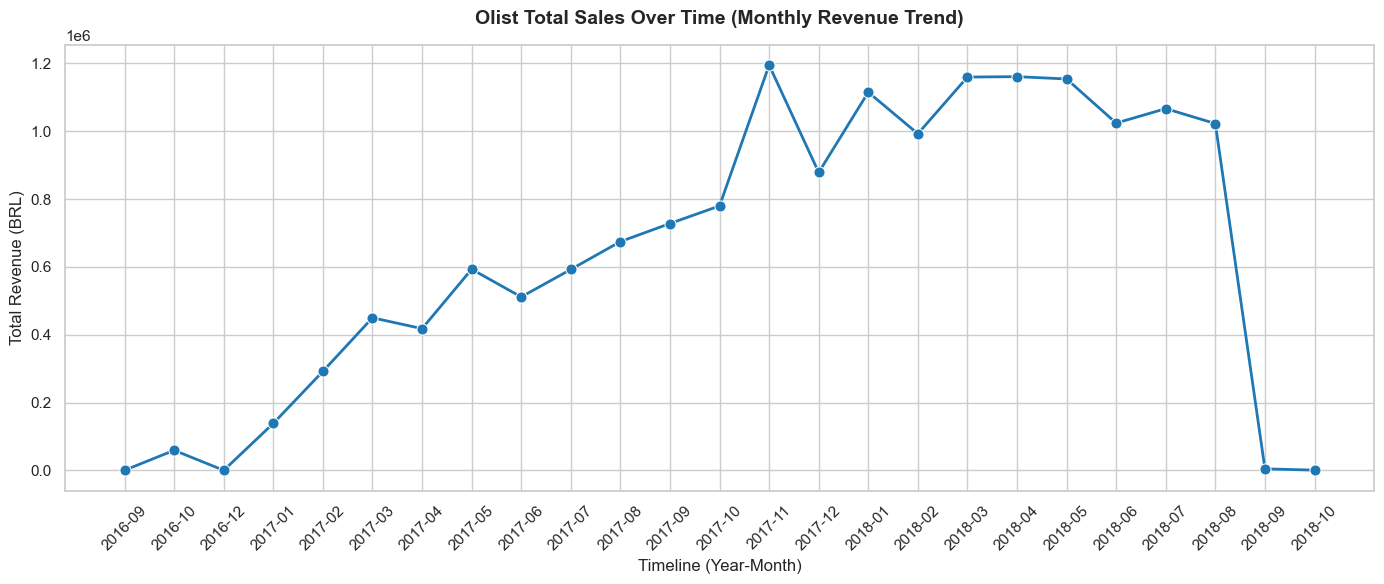

In [92]:
# 1. Prepare Year-Month Column on your Clean DataFrame

# Make sure the timestamp is in datetime format first
payments_df['order_purchase_timestamp'] = pd.to_datetime(payments_df['order_purchase_timestamp'])

# Extract Year-Month as a clean string for aggregation
payments_df['Year_Month'] = payments_df['order_purchase_timestamp'].dt.to_period('M').astype(str)


# 2. Aggregate Monthly Sales Volume (Mathematically True)

monthly_sales_clean = (
    payments_df
    .groupby('Year_Month')['payment_value']
    .sum()
    .reset_index()
)
monthly_sales_clean.columns = ['Year_Month', 'Total_Revenue_BRL']

# Sort chronologically to maintain proper time series alignment
monthly_sales_clean = monthly_sales_clean.sort_values('Year_Month')



# 3. Plot Clean Monthly Revenue Trend Line
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=monthly_sales_clean, 
    x='Year_Month', 
    y='Total_Revenue_BRL', 
    marker='o', 
    markersize=8, 
    linewidth=2, 
    color='#1f77b4'
)

plt.title('Olist Total Sales Over Time (Monthly Revenue Trend)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion: Consistent Growth: From September 2016 to September 2017, Olist showed strong, healthy revenue growth as the platform expanded.

- Holiday Peak: November 2017 shows a massive revenue spike driven entirely by Black Friday shopping.

- Data Limit: The sharp decline in August/September 2018 does not represent a business drop, but rather the cutoff point where data collection for this project ended.

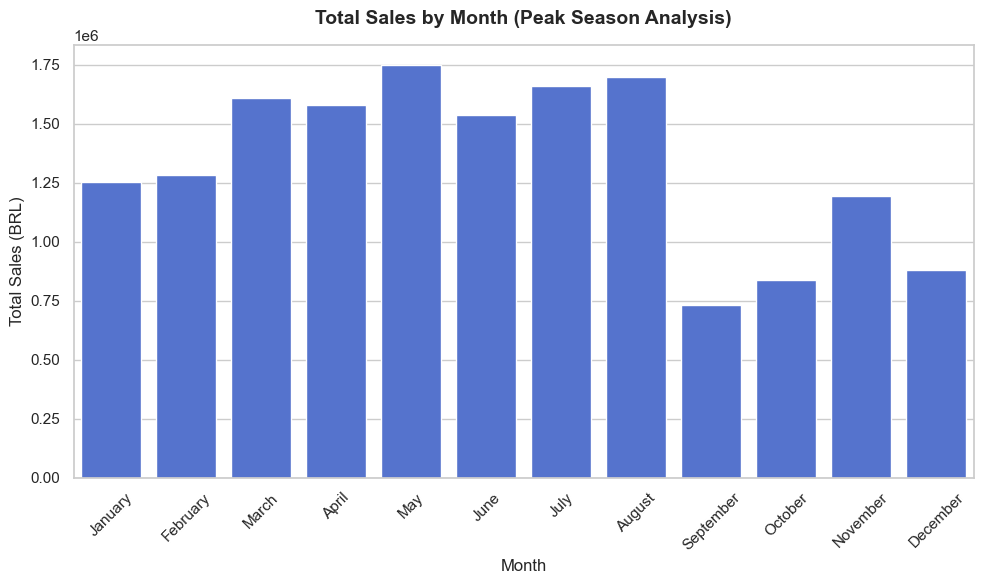

In [93]:
# ==========================================================
# 1. Extract Month Names safely from your uninflated DataFrame
# ==========================================================
payments_df['order_purchase_timestamp'] = pd.to_datetime(payments_df['order_purchase_timestamp'])
payments_df['order_month_name'] = payments_df['order_purchase_timestamp'].dt.strftime('%B')

# 2. Define the correct order of months so they don't sort alphabetically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# ==========================================================
# 3. Aggregate payments cleanly by month name
# ==========================================================
monthly_sales_seasonal = (
    payments_df
    .groupby('order_month_name')['payment_value']
    .sum()
)

# Reindex ensures chronological order (January to December)
monthly_sales_seasonal = monthly_sales_seasonal.reindex(index=month_order).reset_index()

# ==========================================================
# 4. Create the Uninflated Seasonal Bar Chart
# ==========================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(data=monthly_sales_seasonal, x='order_month_name', y='payment_value', color='royalblue')

# Add clear labels
plt.title('Total Sales by Month (Peak Season Analysis)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Comment on Monthly Revenue Seasonality:
- 1. The first half of the year (January to August) shows consistently high sales.
- 2. May is the absolute peak of this period, heavily driven by Mother's Day shopping.
- 3. A visible decline occurs from September to December, with September being the lowest sales month as consumers likely save budget right before the Q4 holiday rush.

#### B) Delivery performance

Analyze:

- Average actual delivery time
- Late vs on-time deliveries
- Distribution of delivery_delta
- Does delay affect reviews?

Important insight question:

Do late deliveries cause low ratings?

In [94]:
# 1. Filter for delivered orders only to get accurate shipping metrics
df_delivered = master_df[master_df['order_status'] == 'delivered'].copy()

# 2. Calculate the average delivery times
avg_actual_days = df_delivered['actual_delivery_days'].mean()
avg_estimated_days = df_delivered['estimated_delivery_days'].mean()
avg_delta = df_delivered['delivery_delta'].mean()

print("==================================================")
print("          DELIVERY PERFORMANCE METRICS            ")
print("==================================================")
print(f"Average Days to Arrive at Customer: {avg_actual_days:.1f} days")
print(f"Average Days Promised to Customer: {avg_estimated_days:.1f} days")
print(f"Average Days Early (Positive = Early): {avg_delta:.1f} days")
print("==================================================")

          DELIVERY PERFORMANCE METRICS            
Average Days to Arrive at Customer: 12.0 days
Average Days Promised to Customer: 23.5 days
Average Days Early (Positive = Early): 11.5 days


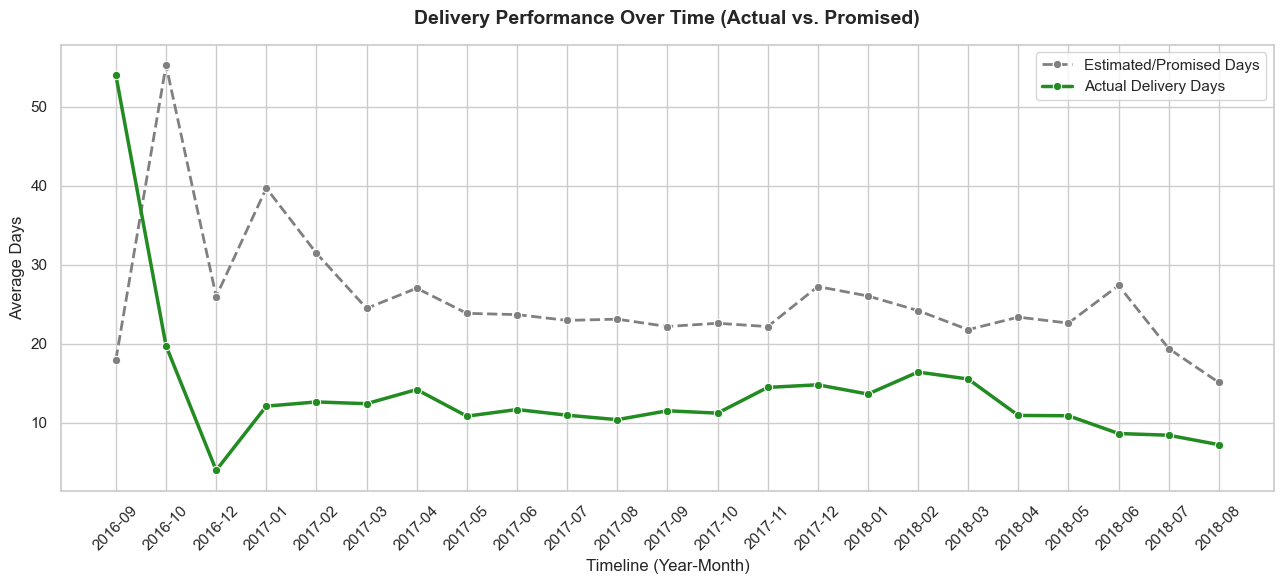

In [95]:
# 1. Group by month and calculate the averages over time
df_delivered['order_year_month_str'] = df_delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)
delivery_trend = df_delivered.groupby('order_year_month_str')[['actual_delivery_days', 'estimated_delivery_days']].mean().reset_index()

# 2. Plot the comparison lines
plt.figure(figsize=(13, 6))
sns.lineplot(data=delivery_trend, x='order_year_month_str', y='estimated_delivery_days', 
             marker='o', color='gray', linestyle='--', linewidth=2, label='Estimated/Promised Days')
sns.lineplot(data=delivery_trend, x='order_year_month_str', y='actual_delivery_days', 
             marker='o', color='forestgreen', linewidth=2.5, label='Actual Delivery Days')

# 3. Add clean labels
plt.title('Delivery Performance Over Time (Actual vs. Promised)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Average Days', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Conclusion (Delivery Performance):

- Initial Logistics Bottleneck: In September 2016 (launch month), actual delivery times exceeded estimates due to early-stage operational challenges.

- Successful Operational Optimization: Starting in October 2016, Olist successfully optimized its logistics. For the remainder of the timeline, actual delivery days (12.0 days average) remained significantly lower than promised dates (23.5 days average).

- Strategic Buffer: This 11.5-day gap represents an "under-promise and over-deliver" strategy that ensures high customer satisfaction and protects against unexpected shipping delays.

     IMPACT OF DELIVERY DELAYS ON RATINGS         
is_late  avg_score  total_orders
   Late   2.443168          8270
On-Time   4.207520        106592


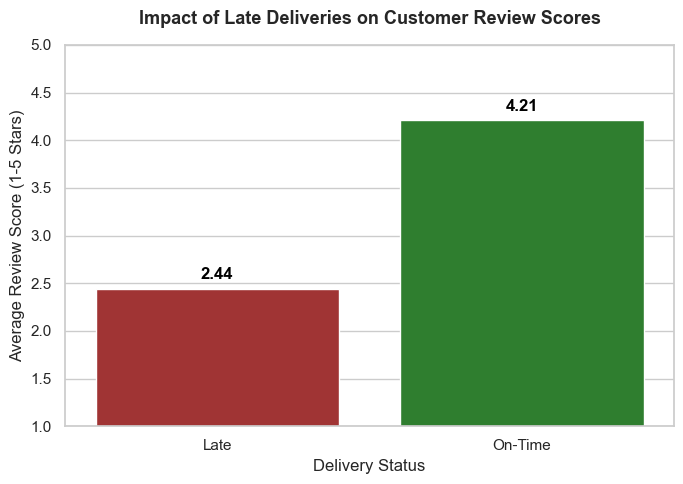

In [96]:
# Do late deliveries cause low ratings?

# 1. Create a binary flag: Was the delivery late?
# (Note: delivery_delta = estimated_delivery_days - actual_delivery_days. If negative, it means it took longer than estimated)
df_delivered['is_late'] = df_delivered['delivery_delta'].apply(lambda x: 'Late' if x < 0 else 'On-Time')

# 2. Group and explicitly name the columns right inside the aggregation function
late_vs_ontime = df_delivered.groupby('is_late').agg(
    avg_score=('review_score', 'mean'),
    total_orders=('review_score', 'count')
).reset_index()

print("==================================================")
print("     IMPACT OF DELIVERY DELAYS ON RATINGS         ")
print("==================================================")
print(late_vs_ontime.to_string(index=False))
print("==================================================")

# 3. Create the bar chart using our new explicit column names
plt.figure(figsize=(7, 5))
sns.barplot(data=late_vs_ontime, x='is_late', y='avg_score', hue='is_late' , palette=['firebrick', 'forestgreen'])
plt.title('Impact of Late Deliveries on Customer Review Scores', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score (1-5 Stars)')
plt.ylim(1, 5)

# 4. Write numbers safely above the bars
for index, row in late_vs_ontime.iterrows():
    plt.text(index, row['avg_score'] + 0.1, f"{row['avg_score']:.2f}", color='black', ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

Do late deliveries cause low ratings?

- The answer is yes, as we can see in bar chart Late orders has low rating average, while the orders delivered On-Time has high rating average.

#### C) Customer Behavior Analysis

Ask:

- How many orders per customer?
- Repeat vs one-time customers
- Purchase frequency by hour/day
- What is the Average Order Value?
- What are the preferred payment methods?

In [97]:
# 1. Count how many orders each unique customer made
customer_counts = master_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_counts.columns = ['customer_unique_id', 'order_count']

# 2. Categorize them as One-time vs Repeat
customer_counts['customer_type'] = customer_counts['order_count'].apply(lambda x:'One-Time Customer' if x == 1 else 'Repeat Customer')

# 3. Calculate percentages
loyalty = customer_counts['customer_type'].value_counts(normalize=True).reset_index()
loyalty.columns = ['customer_type', 'percentage']
loyalty['percentage'] = loyalty['percentage'] * 100

print("==================================================")
print("          CUSTOMER RETENTION METRICS              ")
print("==================================================")

for idx, row in loyalty.iterrows():
    print(f"{row['customer_type']}: {row['percentage']:.2f}%")

print("==================================================")

          CUSTOMER RETENTION METRICS              
One-Time Customer: 96.88%
Repeat Customer: 3.12%


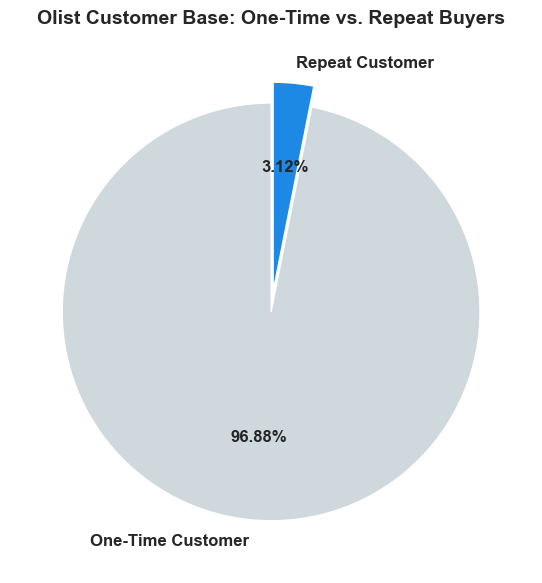

In [98]:
plt.figure(figsize=(6, 6))
plt.pie(
    loyalty['percentage'], 
    labels=loyalty['customer_type'], 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=['#cfd8dc', '#1e88e5'], 
    explode=(0, 0.10),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Olist Customer Base: One-Time vs. Repeat Buyers', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [99]:
# 1. Count the number of unique orders for each hour
hourly_orders = master_df.groupby('order_hour')['order_id'].nunique().reset_index()
hourly_orders.columns = ['hour_of_day', 'total_orders']

print("==================================================")
print("          PEAK SHOPPING HOURS            ")
print("==================================================")
print(hourly_orders.sort_values(by='total_orders', ascending=False).to_string(index=False))
print("==================================================")

          PEAK SHOPPING HOURS            
 hour_of_day  total_orders
          16          6675
          11          6578
          14          6569
          13          6518
          15          6454
          21          6217
          20          6193
          10          6177
          17          6150
          12          5995
          19          5982
          22          5816
          18          5769
           9          4785
          23          4123
           8          2967
           0          2394
           7          1231
           1          1170
           2           510
           6           502
           3           272
           4           206
           5           188


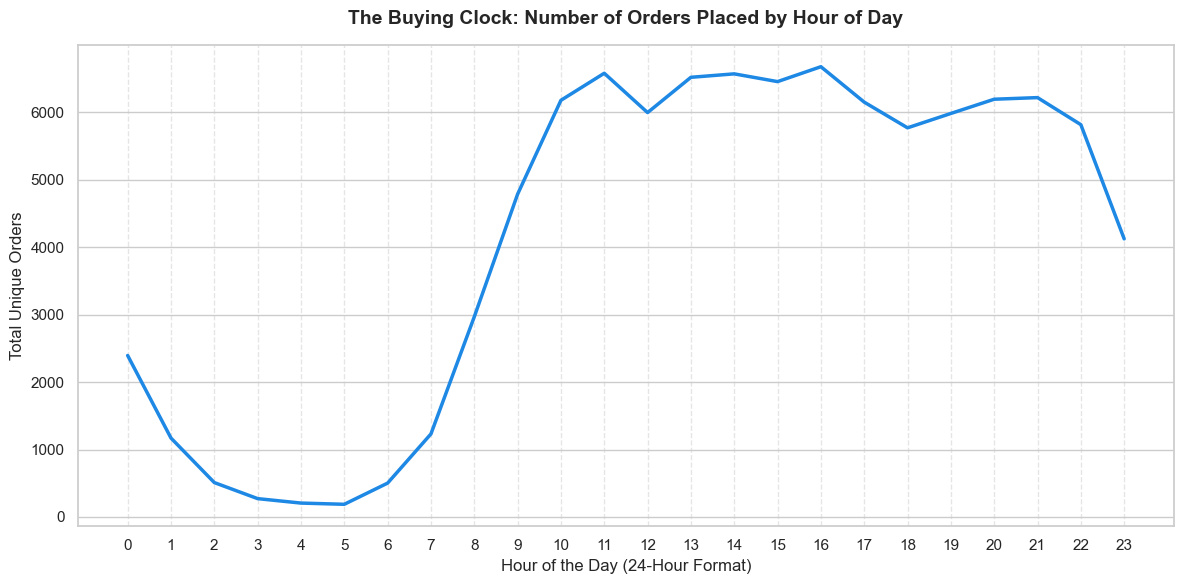

In [100]:
# plot peak shopping hour in day

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_orders,
    x='hour_of_day',
    y='total_orders',
    color='#1e88e5', 
    linewidth=2.5,
)

plt.title('The Buying Clock: Number of Orders Placed by Hour of Day', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Total Unique Orders', fontsize=12)
plt.xticks(range(0, 24)) # Force show every single hour from 0 to 23
plt.grid(axis='x', linestyle='--', alpha=0.5) # Add soft vertical grid lines to guide the eye
plt.tight_layout()
plt.show()

Conclusion (Hourly Purchasing Patterns):

- Peak Activity Window: E-commerce activity is highly concentrated between 10:00 AM and 10:00 PM, showing sustained customer engagement throughout the day.

- Daily Peak: Maximum transaction volume occurs at 4:00 PM (Hour 16), identifying a critical daily window for real-time marketing push notifications, live customer support availability, and flash sales.

- Downtime: The primary shopping dead-zone occurs between Midnight and 8:00 AM, representing optimal windows for scheduled platform maintenance and database updates.

          ORDERS BY DAY OF THE WEEK               
day_of_week  total_orders
     Monday         16196
    Tuesday         15963
  Wednesday         15552
   Thursday         14761
     Friday         14122
   Saturday         10887
     Sunday         11960


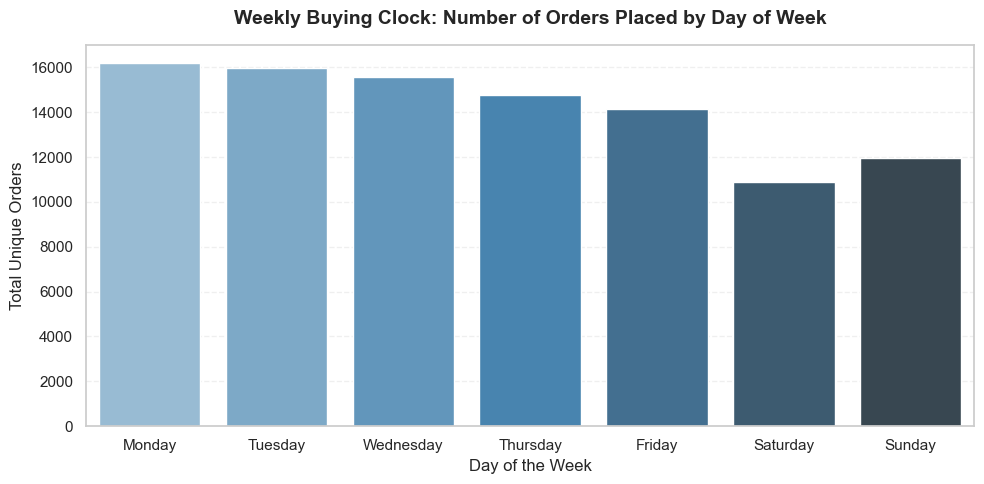

In [101]:
# 2. Count the number of unique orders for each Day
weekly_orders = master_df.groupby('order_day_name')['order_id'].nunique().reset_index()
weekly_orders.columns = ['day_of_week', 'total_orders']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_orders['day_of_week'] = pd.Categorical(weekly_orders['day_of_week'], categories=day_order, ordered=True)
weekly_orders = weekly_orders.sort_values('day_of_week')

print("==================================================")
print("          ORDERS BY DAY OF THE WEEK               ")
print("==================================================")
print(weekly_orders.to_string(index=False))
print("==================================================")

# Create a bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=weekly_orders,
    x='day_of_week',
    y='total_orders',
    hue='day_of_week',
    palette='Blues_d', 
    legend=False
)

plt.title('Weekly Buying Clock: Number of Orders Placed by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Unique Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion (Weekly Purchasing Patterns):

- Weekday Dominance: Shopping volume is heavily concentrated during the workweek (Monday through Friday), with Monday serving as the highest revenue-generating day of the week.

- Weekend Slump: Order volume experiences a drop on the weekend, hitting its absolute lowest point on Saturday.

- Strategic Action: Marketing budgets and promotional email campaigns should focus heavily on Monday mornings and mid-week slots when user engagement is at its peak, rather than wasting ad spend on weekends.

In [102]:
# 1. Sum up all payments to find the total money spent per individual order
orders_total = payments_df.groupby('order_id')['payment_value'].sum().reset_index()

# 2. Calculate the overall Average Order Value (Mean)
average_order_value = orders_total['payment_value'].mean()
median_order_value = orders_total['payment_value'].median()

print("==================================================")
print("             AVERAGE ORDER VALUE           ")
print("==================================================")
print(f"True Average Order Value (Mean):   R$ {average_order_value:.2f}")
print(f"Typical Order Value (Median):      R$ {median_order_value:.2f}")
print("==================================================")


             AVERAGE ORDER VALUE           
True Average Order Value (Mean):   R$ 160.99
Typical Order Value (Median):      R$ 105.29


In [103]:
# 1. Payment type and count transactions
payment_summary = order_payments['payment_type'].value_counts().reset_index()
payment_summary.columns = ['payment_type', 'transaction_count']

# 2. Calculate Percentage
total_tx = payment_summary['transaction_count'].sum()
payment_summary['percentage'] = (payment_summary['transaction_count'] / total_tx) * 100

print("==================================================")
print("       MOST POPULAR PAYMENT METHODS (UNINFLATED)  ")
print("==================================================")
print(payment_summary.to_string(index=False, formatters={
    'transaction_count': '{:,}'.format, 
    'percentage': '{:.3f}%'.format
}))
print("==================================================")

       MOST POPULAR PAYMENT METHODS (UNINFLATED)  
payment_type transaction_count percentage
 credit_card            76,795    73.922%
      boleto            19,784    19.044%
     voucher             5,775     5.559%
  debit_card             1,529     1.472%
 not_defined                 3     0.003%


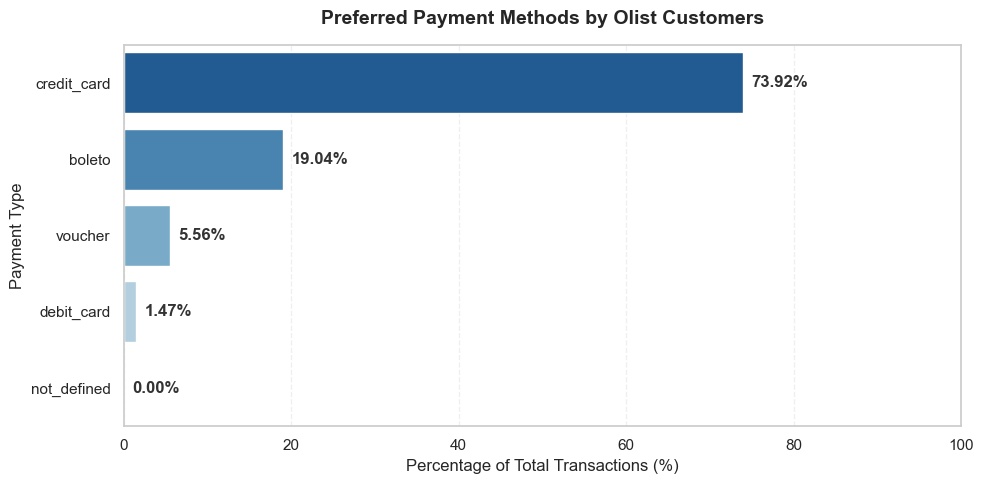

In [104]:
# Create a horizontal bar chart for the payment methods

plt.figure(figsize=(10, 5))
sns.barplot(
    data=payment_summary,
    x='percentage',
    y='payment_type',
    hue='payment_type',
    palette='Blues_r',
    legend=False
)

# Clean up visual elements
plt.title('Preferred Payment Methods by Olist Customers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Transactions (%)', fontsize=12)
plt.ylabel('Payment Type', fontsize=12)
plt.xlim(0, 100)

# Add data labels to the end of each bar for scannability
for idx, row in payment_summary.iterrows():
    plt.text(
        row['percentage'] + 1,      # Push text slightly to the right of the bar edge
        idx,                        # Vertical row index position
        f"{row['percentage']:.2f}%",# Formatted text string
        va='center', 
        fontweight='bold', 
        color='#333333'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Conclusion (Payment Preferences):

- Credit Card Dominance (74%): Credit cards are the primary engine of Olist sales, driven heavily by consumer reliance on interest-free monthly installment choices (payment_installments).

- The Critical Boleto Safe-Net (19%): Nearly 1 in 5 orders rely entirely on the alternative boleto cash-voucher network, proving that eliminating cash payment alternatives would immediately slash customer conversion channels.

- Alternative Methods (7% combined): Vouchers, debit cards, and unclassified types comprise a minor fringe segment of platform transaction volumes.

#### D) Product & category performance

Ask:

- Top categories by revenue
- Top categories by order count
- Categories with highest delays or bad reviews

             TOP 10 PRODUCT CATEGORIES BY TOTAL REVENUE             
product_category_name_english   total_revenue total_orders avg_item_price
                health_beauty R$ 1,301,947.97        8,836      R$ 129.78
                watches_gifts R$ 1,254,322.95        5,624      R$ 201.89
               bed_bath_table R$ 1,107,249.09        9,417       R$ 92.36
               sports_leisure R$ 1,029,603.88        7,720      R$ 114.35
        computers_accessories   R$ 950,053.69        6,689      R$ 116.57
              furniture_decor   R$ 772,096.17        6,449       R$ 87.42
                   housewares   R$ 668,880.94        5,884       R$ 90.63
                   cool_stuff   R$ 664,637.13        3,632      R$ 166.20
                         auto   R$ 618,395.50        3,897      R$ 140.54
                 garden_tools   R$ 519,473.33        3,518      R$ 113.18


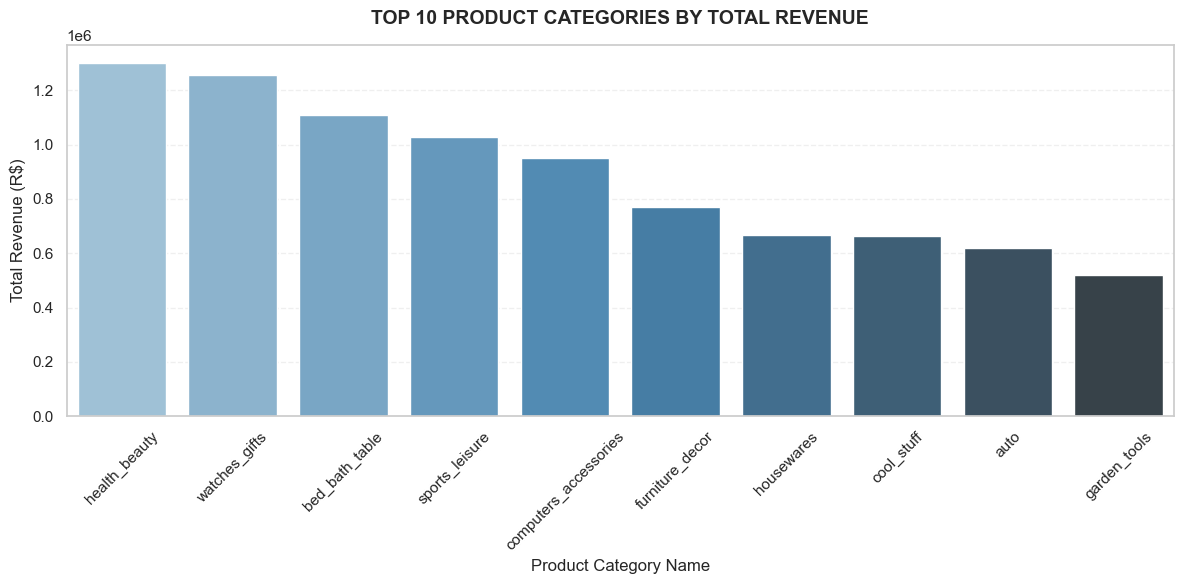

In [105]:
# 1. Aggregate total revenue, order counts, and mean price per category
category_summary = master_df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_item_price=('price', 'mean')
).reset_index()

# 2. Sort by Revenue to see top performers
top_revenue = category_summary.sort_values(by='total_revenue', ascending=False).head(10)

print("=====================================================================")
print("             TOP 10 PRODUCT CATEGORIES BY TOTAL REVENUE             ")
print("=====================================================================")
print(top_revenue.to_string(index=False, formatters={
    'total_revenue': 'R$ {:,.2f}'.format,
    'total_orders': '{:,}'.format,
    'avg_item_price': 'R$ {:,.2f}'.format
}))
print("=====================================================================")

# 3. Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_revenue,
    x='product_category_name_english',
    y='total_revenue',
    hue='product_category_name_english',
    palette='Blues_d', 
    legend=False
)

plt.title('TOP 10 PRODUCT CATEGORIES BY TOTAL REVENUE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category Name', fontsize=12)
plt.ylabel('Total Revenue (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

             TOP 10 PRODUCT CATEGORIES BY ORDER COUNT                
product_category_name_english   total_revenue total_orders avg_item_price
               bed_bath_table R$ 1,107,249.09        9,417       R$ 92.36
                health_beauty R$ 1,301,947.97        8,836      R$ 129.78
               sports_leisure R$ 1,029,603.88        7,720      R$ 114.35
        computers_accessories   R$ 950,053.69        6,689      R$ 116.57
              furniture_decor   R$ 772,096.17        6,449       R$ 87.42
                   housewares   R$ 668,880.94        5,884       R$ 90.63
                watches_gifts R$ 1,254,322.95        5,624      R$ 201.89
                    telephony   R$ 339,571.03        4,199       R$ 71.85
                         auto   R$ 618,395.50        3,897      R$ 140.54
                         toys   R$ 501,118.39        3,886      R$ 117.06


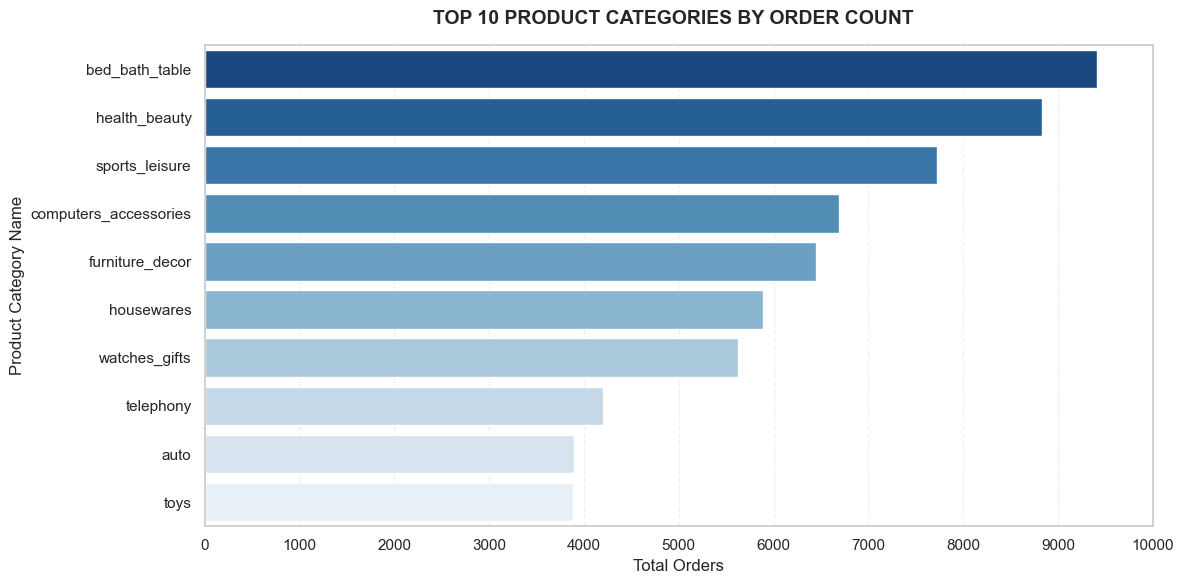

In [106]:
# Sort by order count instead of revenue
top_volume = category_summary.sort_values(by='total_orders', ascending=False).head(10)

print("=====================================================================")
print("             TOP 10 PRODUCT CATEGORIES BY ORDER COUNT                ")
print("=====================================================================")
print(top_volume.to_string(index=False, formatters={
    'total_revenue': 'R$ {:,.2f}'.format,
    'total_orders': '{:,}'.format,
    'avg_item_price': 'R$ {:,.2f}'.format
}))
print("=====================================================================")

# Create a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_volume,
    x='total_orders',
    y='product_category_name_english',
    hue='product_category_name_english',
    palette='Blues_r', 
    legend=False
)

plt.title('TOP 10 PRODUCT CATEGORIES BY ORDER COUNT  ', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('Product Category Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.xticks(range(0, 10001, 1000))
plt.tight_layout()
plt.show()

In [107]:
# 1. Group by category and calculate average review score and average delivery delta
categories_summary = master_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'nunique'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_delta=('delivery_delta', 'mean')
).reset_index()

# Filter for categories with a meaningful sample size (e.g., more than 100 orders) 
# so tiny categories don't skew our findings.
frequent_categories = categories_summary[categories_summary['total_orders'] > 100]

# 2. Sort by lowest review score to find the most problematic categories
worst_reviews = frequent_categories.sort_values(by='avg_review_score', ascending=True).head(10)

print("=====================================================================")
print("          TOP 10 CATEGORIES WITH LOWEST CUSTOMER REVIEWS             ")
print("=====================================================================")
print(worst_reviews.to_string(index=False, formatters={
    'avg_review_score': '{:.2f}'.format,
    'avg_delivery_delta': '{:.1f} days ahead'.format
}))
print("=====================================================================")

          TOP 10 CATEGORIES WITH LOWEST CUSTOMER REVIEWS             
product_category_name_english  total_orders avg_review_score avg_delivery_delta
             office_furniture          1273             3.53    11.0 days ahead
        fashion_male_clothing           112             3.55    11.7 days ahead
              fixed_telephony           217             3.67    14.1 days ahead
                        audio           350             3.84     9.6 days ahead
    construction_tools_safety           167             3.85    11.9 days ahead
               bed_bath_table          9417             3.89    11.1 days ahead
                 home_confort           397             3.91     9.2 days ahead
              furniture_decor          6449             3.91    11.9 days ahead
        furniture_living_room           422             3.91    11.1 days ahead
                          art           202             3.94    12.3 days ahead


In [108]:
# Sort by the smallest delivery delta (closest to 0 or negative) to find shipping bottlenecks
worst_shipping = frequent_categories.sort_values(by='avg_delivery_delta', ascending=True).head(10)

print("=====================================================================")
print("            TOP 10 CATEGORIES WITH LOWEST DELIVERY DELTA             ")
print("=====================================================================")
print(worst_shipping.to_string(index=False, formatters={
    'avg_review_score': '{:.2f}'.format,
    'avg_delivery_delta': '{:.1f} days ahead'.format
}))
print("=====================================================================")

            TOP 10 CATEGORIES WITH LOWEST DELIVERY DELTA             
product_category_name_english  total_orders avg_review_score avg_delivery_delta
                 home_confort           397             3.91     9.2 days ahead
                         food           450             4.23     9.4 days ahead
                        audio           350             3.84     9.6 days ahead
      fashion_underwear_beach           121             3.99    10.1 days ahead
                  electronics          2550             4.04    10.5 days ahead
    construction_tools_lights           244             4.07    10.6 days ahead
              books_technical           260             4.38    10.8 days ahead
                    telephony          4199             3.95    10.8 days ahead
                         auto          3897             4.06    10.8 days ahead
                       drinks           297             4.04    10.9 days ahead


Conclusion (Logistics & Customer Friction):

- The Quality Deficit: Low customer review scores in categories like office_furniture (3.53) and fashion_male_clothing (3.55) are not caused by shipping delays, as both average >11 days ahead of schedule. Instead, friction is driven by product-level issues like sizing errors, manufacturing defects, or complex assembly.

- Logistics Resilience: Across all high-volume product categories, Olist consistently outperforms its estimated arrival dates by a minimum of 9+ days.

- High-Value Success: Categories like food manage tighter logistics schedules beautifully, achieving excellent customer satisfaction (4.23 review score) despite smaller delivery buffers.

#### E) Geospatial Logistics

Ask:

- Regional Concentration (Top States/Cities by Revenue and Volume)
- Freight Economics (How shipping costs vary by region and affect order value)

In [109]:
# ==========================================================
# 1. PREVENT INFLATION: Aggregate regional performance on payments_df
# ==========================================================
state_summary = (
    payments_df
    .groupby('customer_state')
    .agg(
        total_revenue=('payment_value', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

# ==========================================================
# 2. Extract Freight Cost from master_df (where item row metrics are safe)
# ==========================================================
freight_summary = (
    master_df
    .groupby('customer_state')
    .agg(avg_freight_cost=('freight_value', 'mean'))
    .reset_index()
)

# Combine the clean metrics back together
state_summary = pd.merge(state_summary, freight_summary, on='customer_state', how='left')

# ==========================================================
# 3. Calculate True Revenue Share Percentages
# ==========================================================
total_platform_revenue = state_summary['total_revenue'].sum()
state_summary['revenue_share_pct'] = (state_summary['total_revenue'] / total_platform_revenue) * 100

# Sort by highest revenue to isolate dominant hubs
top_states = state_summary.sort_values(by='total_revenue', ascending=False).head(10)

print("=========================================================================")
print("          TOP 10 BRAZILIAN STATES BY REVENUE & FREIGHT ECONOMICS    ")
print("=========================================================================")
print(top_states.to_string(index=False, formatters={
    'total_revenue': 'R$ {:,.2f}'.format,
    'total_orders': '{:,}'.format,
    'avg_freight_cost': 'R$ {:,.2f}'.format,
    'revenue_share_pct': '{:.2f}%'.format
}))
print("=========================================================================")

          TOP 10 BRAZILIAN STATES BY REVENUE & FREIGHT ECONOMICS    
customer_state   total_revenue total_orders avg_freight_cost revenue_share_pct
            SP R$ 5,998,226.96       41,746         R$ 15.19            37.47%
            RJ R$ 2,144,379.69       12,852         R$ 21.09            13.39%
            MG R$ 1,872,257.26       11,635         R$ 20.61            11.70%
            RS   R$ 890,898.54        5,466         R$ 21.81             5.57%
            PR   R$ 811,156.38        5,045         R$ 20.59             5.07%
            SC   R$ 623,086.43        3,637         R$ 21.44             3.89%
            BA   R$ 616,645.82        3,380         R$ 26.30             3.85%
            DF   R$ 355,141.08        2,140         R$ 21.05             2.22%
            GO   R$ 350,092.31        2,020         R$ 22.75             2.19%
            ES   R$ 325,967.55        2,033         R$ 21.98             2.04%


## 6. Customer Segmentation (RFM)

In [114]:
# ==========================================================
# RFM CUSTOMER SEGMENTATION - OLIST E-COMMERCE DATASET
# ==========================================================

# 1. Define Snapshot Date
snapshot_date = payments_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f"Dataset Snapshot Date: {snapshot_date.strftime('%Y-%m-%d')}\n")

# ==========================================================
# 2. Calculate RFM Metrics
# ==========================================================

rfm = (
    payments_df
    .groupby('customer_unique_id')
    .agg(
        recency=('order_purchase_timestamp',
                 lambda x: (snapshot_date - x.max()).days),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum')
    )
    .reset_index()
)

# ==========================================================
# 3. Generate RFM Scores (1-5)
# ==========================================================

# Recency: Lower is better (continuous values -> quintiles are fine)
rfm['R'] = pd.qcut(
    rfm['recency'],
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: Higher is better
# NOTE: ~97% of Olist customers have frequency == 1, so quintile-binning
# (even with rank-based tie-breaking) assigns scores arbitrarily within
# that massive tied group. Score directly off the real order count instead,
# capped at 5 for rare heavy repeaters.
rfm['F'] = rfm['frequency'].clip(upper=5).astype(int)

# Monetary: Higher is better (continuous values -> quintiles are fine)
rfm['M'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# ==========================================================
# 4. Create RFM Scores
# ==========================================================

rfm['RFM_Cell'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

rfm['RFM_Score'] = (rfm['R'] + rfm['F'] + rfm['M'])

# ==========================================================
# 5. Customer Segmentation
# ==========================================================

def assign_segment(row):

    r = row['R']
    f = row['F']
    m = row['M']

    # f >= 2 now means "came back at least once" — that's the
    # meaningful bar for this dataset, not f >= 4.
    if r >= 4 and f >= 2 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 2:
        return 'Loyal Customers'

    elif r >= 4 and m >= 4:
        return 'Potential Loyalists'

    elif r >= 4:
        return 'Recent Customers'

    elif r <= 2 and f >= 2:
        return 'At Risk'

    elif r <= 2 and m >= 4:
        return 'Cannot Lose Them'

    elif r <= 2:
        return 'Lost Customers'

    else:
        return 'Need Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ==========================================================
# 6. Segment Summary
# ==========================================================

segment_summary = (
    rfm['Segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = ['Customer Segment', 'Total Customers']

segment_summary['Percentage Share'] = (segment_summary['Total Customers'] / len(rfm) * 100)

print("=" * 65)
print("                CUSTOMER SEGMENTATION SUMMARY")
print("=" * 65)

print(
    segment_summary.to_string(
        index=False,
        formatters={
            'Total Customers': '{:,}'.format,
            'Percentage Share': '{:.2f}%'.format
        }
    )
)

print("=" * 65)

# ==========================================================
# 7. Preview RFM Table
# ==========================================================

display(rfm.head())

Dataset Snapshot Date: 2018-10-18

                CUSTOMER SEGMENTATION SUMMARY
   Customer Segment Total Customers Percentage Share
     Lost Customers          23,235           24.18%
   Recent Customers          22,470           23.38%
     Need Attention          18,414           19.16%
Potential Loyalists          14,839           15.44%
   Cannot Lose Them          14,141           14.72%
          Champions           1,072            1.12%
            At Risk           1,054            1.10%
    Loyal Customers             871            0.91%


,customer_unique_id,recency,frequency,monetary,R,F,M,RFM_Cell,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,414,9,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411,6,Recent Customers
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112,4,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211,4,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214,7,Cannot Lose Them


Conclusion (Customer Behavioral Segmentation via 3D RFM Model):

- The Retention Bottleneck (The 3% Core): Transitioning from textbook rankings to a business-accurate frequency threshold ($F \ge 2$) reveals a stark operational reality: true repeat loyalty is incredibly rare on Olist. Champions (1.12%), At Risk (1.10%), and Loyal Customers (0.91%) combine for just over 3.1% of the entire user base. Olist is a powerful customer acquisition machine, but it fundamentally functions as a single-purchase marketplace.

- The High-Value Growth Frontier: Your second-largest pool of active buyers sits in 'Potential Loyalists' (15.44%). Because your custom logic accurately isolates these as high-spending, recent, first-time buyers ($R \ge 4, M \ge 4, F = 1$), this cohort represents Olist’s highest-leverage financial opportunity.

- 🎯 Refactored Strategic Action Plan:
1. The Second-Purchase Bridge (For 'Potential Loyalists' & 'Recent Customers'): Since these two groups represent nearly 39% of your active, recent audience, implement automated, time-bound post-purchase incentives (e.g., "Get R$ 25 off your next order within 14 days") to explicitly push single-swipe buyers into their critical second transaction.
2. Slipping Customer Nurturing (For 'Need Attention'): Occupying 19.16% of your database, these are moderate-spend, single-purchase buyers whose recency is starting to fade. They require immediate personalized cross-category recommendations based on their initial purchase before they permanently drift into 'Lost Customers'.
3. Elite Circle Protection (For Champions & Loyal): Because a repeat customer is so mathematically rare on this platform, they are incredibly valuable. Treat Champions (1.12%) with specialized loyalty perks or priority customer service, and target the 'At Risk' (1.10%) repeat buyers with aggressive, high-margin win-back email campaigns.

## 7. Dashboard Development

In [129]:
# Save these DataFrames so app.py can load them without throwing an error
payments_df.to_csv('clean_files/payments_clean.csv', index=False)
order_payments.to_csv('clean_files/order_payments_clean.csv', index=False)
rfm.to_csv('clean_files/rfm_clean.csv', index=False)
master_df.to_csv('clean_files/master_clean.csv', index=False)

print("CSVs exported successfully!")

CSVs exported successfully!


I Export these csv files to use them in streamlit dashboard app